# Behavioral searchlight RSA: pleasant/unpleasant and neutral subsets

This notebook derives two analyses from the same 60-condition data and behavioral RDM used by `searchlight_behavioral_final.ipynb`:

1. **40-condition pleasant + unpleasant RDM**: conditions 0–19 and 40–59.
2. **20-condition neutral RDM**: conditions 20–39.

For each case, subject-level searchlight/behavioral-RDM Spearman correlations are Fisher-z transformed. A voxelwise one-sample t-test across 20 subjects is then FDR-corrected using Benjamini–Hochberg at `q = 0.01`, matching the final inferential cell of the source notebook. The saved NIfTI images contain signed t-values only at FDR-significant searchlight centers; all other voxels are zero.

Long-running subject-level results are cached under `outputs/searchlight_results/SS`, so interrupted runs can resume without recomputing completed subjects.

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from IPython.display import display
from nilearn import plotting
from nilearn.image import new_img_like
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import (
    evaluate_models_searchlight,
    get_searchlight_RDMs,
    get_volume_searchlight,
)
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from tqdm.auto import tqdm

PROJECT_DIR = Path(r"\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight")
DATA_DIR = PROJECT_DIR.parent / "IAPS_fMRI_RSA"
BEHAVIORAL_DIR = PROJECT_DIR.parent / "IAPS_behavioral_RDM"
SCORE_DIR = PROJECT_DIR / "outputs" / "searchlight_results" / "SS"
MAP_DIR = PROJECT_DIR / "outputs" / "tBrainmap" / "SS"
SCORE_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

SEARCHLIGHT_RADIUS = 5
MASK_THRESHOLD = 0.5
N_JOBS = 6
N_SUBJECTS = 20
FDR_ALPHA = 0.01
FORCE_RECOMPUTE = False

print(f"Project: {PROJECT_DIR}")
print(f"Maps will be saved in: {MAP_DIR}")

Project: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight
Maps will be saved in: \\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS


C:\Users\simona.sartan\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and validate the shared 60-condition inputs

In [2]:
mask = np.load(PROJECT_DIR / "mask.npy")
allsub_avg = np.load(PROJECT_DIR / "allsub_avg.npy", mmap_mode="r")
behavioral_rdm_60 = pd.read_csv(
    BEHAVIORAL_DIR / "rdm_behavioral_normed.csv", index_col=0
).to_numpy(dtype=float)
template_img = nib.load(DATA_DIR / "fMRI_singletrial_betas" / "nifti" / "Nt1.img")

assert mask.shape == (53, 63, 46), f"Unexpected mask shape: {mask.shape}"
assert allsub_avg.shape == (N_SUBJECTS, 60, int(np.prod(mask.shape))), (
    f"Unexpected subject-data shape: {allsub_avg.shape}"
)
assert behavioral_rdm_60.shape == (60, 60), (
    f"Unexpected behavioral RDM shape: {behavioral_rdm_60.shape}"
)
assert np.allclose(behavioral_rdm_60, behavioral_rdm_60.T, equal_nan=True), (
    "Behavioral RDM is not symmetric."
)

# Original condition order: 20 pleasant, 20 neutral, 20 unpleasant.
CASE_INDICES = {
    "pleasant_unpleasant_40": np.r_[0:20, 40:60],
    "neutral_20": np.arange(20, 40),
}
CASE_RDMS = {
    case_name: behavioral_rdm_60[np.ix_(indices, indices)]
    for case_name, indices in CASE_INDICES.items()
}

for case_name, indices in CASE_INDICES.items():
    print(case_name, "conditions:", indices.tolist())
    print("RDM shape:", CASE_RDMS[case_name].shape)

pleasant_unpleasant_40 conditions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
RDM shape: (40, 40)
neutral_20 conditions: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
RDM shape: (20, 20)


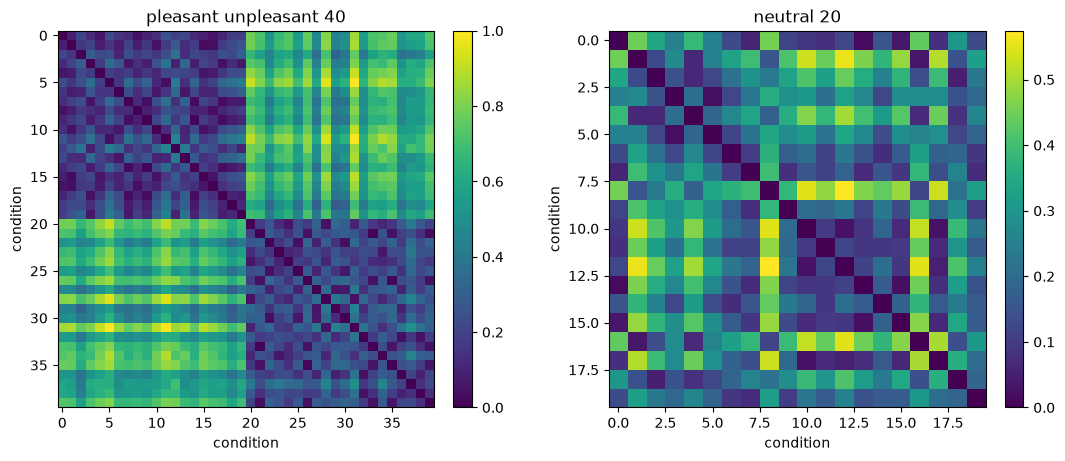

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (case_name, rdm) in zip(axes, CASE_RDMS.items()):
    image = ax.imshow(rdm, cmap="viridis")
    ax.set_title(case_name.replace("_", " "))
    ax.set_xlabel("condition")
    ax.set_ylabel("condition")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Define the radius-5 searchlight and reusable analysis functions

In [4]:
centers, neighbors = get_volume_searchlight(
    mask, radius=SEARCHLIGHT_RADIUS, threshold=MASK_THRESHOLD
)
centers = np.asarray(centers)
print(f"Searchlight centers: {len(centers):,}")
print(
    "Voxels per sphere (min/mean/max):",
    min(map(len, neighbors)),
    f"{np.mean(list(map(len, neighbors))):.1f}",
    max(map(len, neighbors)),
)

Finding searchlights...:   0%|          | 0/59159 [00:00<?, ?it/s]

Finding searchlights...:   1%|▏         | 868/59159 [00:00<00:06, 8520.10it/s]

Finding searchlights...:   3%|▎         | 1721/59159 [00:00<00:08, 6631.80it/s]

Finding searchlights...:   4%|▍         | 2598/59159 [00:00<00:07, 7415.24it/s]

Finding searchlights...:   6%|▌         | 3376/59159 [00:00<00:07, 7545.60it/s]

Finding searchlights...:   7%|▋         | 4229/59159 [00:00<00:07, 7832.94it/s]

Finding searchlights...:   8%|▊         | 5025/59159 [00:00<00:08, 6259.72it/s]

Finding searchlights...:  10%|▉         | 5716/59159 [00:00<00:08, 6431.41it/s]

Finding searchlights...:  11%|█         | 6397/59159 [00:00<00:09, 5572.17it/s]

Finding searchlights...:  12%|█▏        | 6995/59159 [00:01<00:09, 5636.05it/s]

Finding searchlights...:  13%|█▎        | 7588/59159 [00:01<00:17, 3017.42it/s]

Finding searchlights...:  14%|█▎        | 8056/59159 [00:01<00:15, 3293.01it/s]

Finding searchlights...:  15%|█▍        | 8634/59159 [00:01<00:13, 3763.50it/s]

Finding searchlights...:  16%|█▌        | 9341/59159 [00:01<00:11, 4459.23it/s]

Finding searchlights...:  17%|█▋        | 9895/59159 [00:01<00:11, 4305.81it/s]

Finding searchlights...:  18%|█▊        | 10401/59159 [00:02<00:11, 4395.47it/s]

Finding searchlights...:  19%|█▊        | 10961/59159 [00:02<00:10, 4691.52it/s]

Finding searchlights...:  19%|█▉        | 11475/59159 [00:02<00:10, 4615.19it/s]

Finding searchlights...:  20%|██        | 11968/59159 [00:02<00:10, 4441.54it/s]

Finding searchlights...:  21%|██        | 12543/59159 [00:02<00:09, 4763.01it/s]

Finding searchlights...:  22%|██▏       | 13174/59159 [00:02<00:08, 5162.69it/s]

Finding searchlights...:  23%|██▎       | 13708/59159 [00:02<00:09, 4943.91it/s]

Finding searchlights...:  24%|██▍       | 14216/59159 [00:02<00:09, 4740.87it/s]

Finding searchlights...:  25%|██▌       | 14901/59159 [00:02<00:08, 5260.15it/s]

Finding searchlights...:  26%|██▌       | 15438/59159 [00:03<00:08, 5029.52it/s]

Finding searchlights...:  27%|██▋       | 16187/59159 [00:03<00:07, 5604.73it/s]

Finding searchlights...:  28%|██▊       | 16757/59159 [00:03<00:08, 5151.21it/s]

Finding searchlights...:  29%|██▉       | 17319/59159 [00:03<00:07, 5230.90it/s]

Finding searchlights...:  30%|███       | 17945/59159 [00:03<00:07, 5406.64it/s]

Finding searchlights...:  31%|███▏      | 18493/59159 [00:03<00:07, 5244.64it/s]

Finding searchlights...:  32%|███▏      | 19221/59159 [00:03<00:06, 5776.13it/s]

Finding searchlights...:  34%|███▎      | 19939/59159 [00:03<00:06, 6167.46it/s]

Finding searchlights...:  35%|███▍      | 20564/59159 [00:03<00:06, 5692.41it/s]

Finding searchlights...:  36%|███▌      | 21298/59159 [00:04<00:06, 6131.05it/s]

Finding searchlights...:  37%|███▋      | 21923/59159 [00:04<00:06, 5511.35it/s]

Finding searchlights...:  38%|███▊      | 22493/59159 [00:04<00:07, 4869.67it/s]

Finding searchlights...:  39%|███▉      | 23003/59159 [00:04<00:07, 4793.47it/s]

Finding searchlights...:  40%|███▉      | 23541/59159 [00:04<00:07, 4922.38it/s]

Finding searchlights...:  41%|████      | 24046/59159 [00:04<00:07, 4771.97it/s]

Finding searchlights...:  42%|████▏     | 24613/59159 [00:04<00:06, 5008.68it/s]

Finding searchlights...:  43%|████▎     | 25399/59159 [00:04<00:05, 5745.00it/s]

Finding searchlights...:  44%|████▍     | 25984/59159 [00:05<00:06, 5150.70it/s]

Finding searchlights...:  45%|████▍     | 26517/59159 [00:05<00:06, 5008.78it/s]

Finding searchlights...:  46%|████▌     | 27030/59159 [00:05<00:06, 4949.85it/s]

Finding searchlights...:  47%|████▋     | 27533/59159 [00:05<00:06, 4937.26it/s]

Finding searchlights...:  47%|████▋     | 28088/59159 [00:05<00:06, 5096.20it/s]

Finding searchlights...:  49%|████▉     | 28848/59159 [00:05<00:05, 5785.58it/s]

Finding searchlights...:  50%|████▉     | 29434/59159 [00:05<00:05, 5751.84it/s]

Finding searchlights...:  51%|█████     | 30014/59159 [00:05<00:05, 5530.46it/s]

Finding searchlights...:  52%|█████▏    | 30572/59159 [00:05<00:05, 5469.13it/s]

Finding searchlights...:  53%|█████▎    | 31122/59159 [00:06<00:09, 2925.50it/s]

Finding searchlights...:  54%|█████▎    | 31677/59159 [00:06<00:08, 3389.58it/s]

Finding searchlights...:  54%|█████▍    | 32185/59159 [00:06<00:07, 3730.68it/s]

Finding searchlights...:  55%|█████▌    | 32661/59159 [00:06<00:06, 3919.91it/s]

Finding searchlights...:  56%|█████▋    | 33362/59159 [00:06<00:05, 4653.92it/s]

Finding searchlights...:  57%|█████▋    | 33899/59159 [00:06<00:05, 4712.16it/s]

Finding searchlights...:  58%|█████▊    | 34421/59159 [00:06<00:05, 4760.21it/s]

Finding searchlights...:  59%|█████▉    | 34977/59159 [00:07<00:04, 4952.45it/s]

Finding searchlights...:  60%|██████    | 35500/59159 [00:07<00:05, 4686.59it/s]

Finding searchlights...:  61%|██████    | 36040/59159 [00:07<00:04, 4861.50it/s]

Finding searchlights...:  62%|██████▏   | 36588/59159 [00:07<00:04, 5006.33it/s]

Finding searchlights...:  63%|██████▎   | 37109/59159 [00:07<00:04, 5052.32it/s]

Finding searchlights...:  64%|██████▎   | 37624/59159 [00:07<00:04, 4343.09it/s]

Finding searchlights...:  65%|██████▍   | 38320/59159 [00:07<00:04, 5020.39it/s]

Finding searchlights...:  66%|██████▌   | 38849/59159 [00:07<00:04, 4840.14it/s]

Finding searchlights...:  67%|██████▋   | 39361/59159 [00:07<00:04, 4892.52it/s]

Finding searchlights...:  67%|██████▋   | 39864/59159 [00:08<00:04, 4786.39it/s]

Finding searchlights...:  68%|██████▊   | 40450/59159 [00:08<00:03, 5072.87it/s]

Finding searchlights...:  69%|██████▉   | 41070/59159 [00:08<00:03, 5371.14it/s]

Finding searchlights...:  70%|███████   | 41615/59159 [00:08<00:03, 5182.69it/s]

Finding searchlights...:  71%|███████   | 42140/59159 [00:08<00:03, 4743.84it/s]

Finding searchlights...:  72%|███████▏  | 42694/59159 [00:08<00:03, 4949.88it/s]

Finding searchlights...:  73%|███████▎  | 43344/59159 [00:08<00:02, 5378.60it/s]

Finding searchlights...:  74%|███████▍  | 43892/59159 [00:08<00:02, 5340.63it/s]

Finding searchlights...:  75%|███████▌  | 44433/59159 [00:08<00:02, 5359.64it/s]

Finding searchlights...:  76%|███████▌  | 44974/59159 [00:09<00:02, 5254.26it/s]

Finding searchlights...:  77%|███████▋  | 45746/59159 [00:09<00:02, 5935.85it/s]

Finding searchlights...:  79%|███████▊  | 46548/59159 [00:09<00:01, 6519.02it/s]

Finding searchlights...:  80%|████████  | 47433/59159 [00:09<00:01, 7194.15it/s]

Finding searchlights...:  82%|████████▏ | 48251/59159 [00:09<00:01, 7446.23it/s]

Finding searchlights...:  83%|████████▎ | 49000/59159 [00:09<00:01, 6240.63it/s]

Finding searchlights...:  84%|████████▍ | 49659/59159 [00:09<00:01, 5471.36it/s]

Finding searchlights...:  85%|████████▍ | 50263/59159 [00:09<00:01, 5581.32it/s]

Finding searchlights...:  86%|████████▋ | 51049/59159 [00:09<00:01, 6165.41it/s]

Finding searchlights...:  87%|████████▋ | 51696/59159 [00:10<00:01, 6045.07it/s]

Finding searchlights...:  88%|████████▊ | 52321/59159 [00:10<00:01, 5995.82it/s]

Finding searchlights...:  89%|████████▉ | 52935/59159 [00:10<00:01, 5514.73it/s]

Finding searchlights...:  90%|█████████ | 53502/59159 [00:10<00:01, 5494.29it/s]

Finding searchlights...:  91%|█████████▏| 54062/59159 [00:10<00:00, 5289.21it/s]

Finding searchlights...:  92%|█████████▏| 54599/59159 [00:10<00:00, 5235.66it/s]

Finding searchlights...:  93%|█████████▎| 55128/59159 [00:10<00:00, 5025.54it/s]

Finding searchlights...:  94%|█████████▍| 55766/59159 [00:10<00:00, 5380.39it/s]

Finding searchlights...:  95%|█████████▌| 56347/59159 [00:10<00:00, 5471.54it/s]

Finding searchlights...:  96%|█████████▌| 56899/59159 [00:11<00:00, 5207.32it/s]

Finding searchlights...:  97%|█████████▋| 57425/59159 [00:11<00:01, 1678.82it/s]

Finding searchlights...:  98%|█████████▊| 57888/59159 [00:12<00:00, 2011.92it/s]

Finding searchlights...:  99%|█████████▉| 58498/59159 [00:12<00:00, 2578.43it/s]

Finding searchlights...: 100%|██████████| 59159/59159 [00:12<00:00, 4845.58it/s]

Found 56949 searchlights


Searchlight centers: 56,949
Voxels per sphere (min/mean/max): 277 483.8 485


In [5]:
def upper_tri(rdm):
    rows, cols = np.triu_indices(rdm.shape[0], k=1)
    return rdm[rows, cols]


def evaluate_case(case_name, condition_indices, model_rdm):
    # Run or resume subject-level searchlight RSA for one condition subset.
    condition_indices = np.asarray(condition_indices)
    model = ModelFixed(case_name, upper_tri(model_rdm))
    expected_center_ids = None
    subject_scores = []

    for subject_index in tqdm(range(N_SUBJECTS), desc=case_name):
        cache_path = SCORE_DIR / f"{case_name}_sub-{subject_index + 1:02d}_scores.npy"

        if cache_path.exists() and not FORCE_RECOMPUTE:
            scores = np.load(cache_path)
            if scores.shape != (len(centers),):
                raise ValueError(
                    f"Cached score shape mismatch in {cache_path}: {scores.shape}"
                )
        else:
            # Load only this subject and this condition subset into memory.
            subject_data = np.nan_to_num(
                np.asarray(allsub_avg[subject_index, condition_indices, :]),
                copy=False,
            )
            image_values = np.arange(len(condition_indices))
            searchlight_rdms = get_searchlight_RDMs(
                subject_data,
                centers,
                neighbors,
                image_values,
                method="correlation",
            )
            evaluation_results = evaluate_models_searchlight(
                searchlight_rdms,
                model,
                eval_fixed,
                method="spearman",
                n_jobs=N_JOBS,
            )
            scores = np.asarray(
                [float(np.asarray(result.evaluations).squeeze()) for result in evaluation_results],
                dtype=np.float32,
            )
            np.save(cache_path, scores)

        subject_scores.append(scores)

        # get_volume_searchlight centers are the voxel IDs used by the RDMs.
        # Keeping this check here protects against cache/configuration mismatch.
        center_ids = centers.astype(int, copy=False)
        if expected_center_ids is None:
            expected_center_ids = center_ids
        elif not np.array_equal(center_ids, expected_center_ids):
            raise RuntimeError("Searchlight center IDs changed between subjects.")

    subject_scores = np.vstack(subject_scores)
    np.save(SCORE_DIR / f"{case_name}_20sub_scores.npy", subject_scores)
    np.save(SCORE_DIR / f"{case_name}_voxel_center_ids.npy", expected_center_ids)
    return subject_scores, expected_center_ids


def second_level_fdr_tmap(subject_scores, center_ids, output_name):
    # Fisher-z, one-sample t-test, BH-FDR, and signed significant-t NIfTI.
    eps = np.finfo(np.float64).eps
    correlations = np.clip(subject_scores.astype(float), -1 + eps, 1 - eps)
    fisher_z = np.arctanh(correlations)
    t_values, p_values = ttest_1samp(fisher_z, popmean=0, axis=0, nan_policy="omit")

    reject = np.zeros(p_values.shape, dtype=bool)
    corrected_p = np.full(p_values.shape, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    reject_finite, corrected_finite = fdrcorrection(
        p_values[finite], alpha=FDR_ALPHA, method="indep", is_sorted=False
    )
    reject[finite] = reject_finite
    corrected_p[finite] = corrected_finite

    map_flat = np.zeros(mask.size, dtype=np.float32)
    significant = reject & np.isfinite(t_values)
    map_flat[np.asarray(center_ids, dtype=int)[significant]] = t_values[significant]
    map_img = new_img_like(template_img, map_flat.reshape(mask.shape), copy_header=True)
    output_path = MAP_DIR / output_name
    nib.save(map_img, output_path)

    return {
        "output": str(output_path),
        "n_centers_tested": int(finite.sum()),
        "n_fdr_significant": int(significant.sum()),
        "n_positive": int(np.sum(significant & (t_values > 0))),
        "n_negative": int(np.sum(significant & (t_values < 0))),
        "min_fdr_p": float(np.nanmin(corrected_p)),
    }

## Run the two subject-level cases

This is the long-running section. Per-subject caches allow the cell to resume after interruption.

In [6]:
case_scores = {}
case_center_ids = {}

for case_name, indices in CASE_INDICES.items():
    scores, center_ids = evaluate_case(case_name, indices, CASE_RDMS[case_name])
    case_scores[case_name] = scores
    case_center_ids[case_name] = center_ids
    print(case_name, "score matrix:", scores.shape)

pleasant_unpleasant_40:   0%|          | 0/20 [00:00<?, ?it/s]

pleasant_unpleasant_40:  10%|█         | 2/20 [00:00<00:01, 14.95it/s]

pleasant_unpleasant_40:  20%|██        | 4/20 [00:00<00:01, 15.58it/s]

pleasant_unpleasant_40:  30%|███       | 6/20 [00:00<00:00, 15.65it/s]

pleasant_unpleasant_40:  40%|████      | 8/20 [00:00<00:00, 16.11it/s]

pleasant_unpleasant_40:  50%|█████     | 10/20 [00:00<00:00, 15.54it/s]

pleasant_unpleasant_40:  60%|██████    | 12/20 [00:00<00:00, 15.10it/s]

pleasant_unpleasant_40:  70%|███████   | 14/20 [00:00<00:00, 16.13it/s]

pleasant_unpleasant_40:  85%|████████▌ | 17/20 [00:01<00:00, 18.04it/s]

pleasant_unpleasant_40:  95%|█████████▌| 19/20 [00:01<00:00, 18.52it/s]

pleasant_unpleasant_40: 100%|██████████| 20/20 [00:01<00:00, 16.97it/s]

pleasant_unpleasant_40 score matrix: (20, 56949)


neutral_20:   0%|          | 0/20 [00:00<?, ?it/s]

neutral_20:  10%|█         | 2/20 [00:00<00:01, 17.52it/s]

neutral_20:  20%|██        | 4/20 [00:00<00:00, 16.44it/s]

neutral_20:  30%|███       | 6/20 [00:00<00:00, 15.84it/s]

neutral_20:  40%|████      | 8/20 [00:00<00:00, 17.02it/s]

neutral_20:  50%|█████     | 10/20 [00:00<00:00, 15.81it/s]

neutral_20:  60%|██████    | 12/20 [00:00<00:00, 16.24it/s]

neutral_20:  70%|███████   | 14/20 [00:00<00:00, 15.59it/s]

neutral_20:  80%|████████  | 16/20 [00:01<00:00, 15.62it/s]

neutral_20:  90%|█████████ | 18/20 [00:01<00:00, 16.72it/s]

neutral_20: 100%|██████████| 20/20 [00:01<00:00, 16.34it/s]

neutral_20: 100%|██████████| 20/20 [00:01<00:00, 16.22it/s]

neutral_20 score matrix: (20, 56949)


## Second-level FDR correction and final NIfTI outputs

In [7]:
output_names = {
    "pleasant_unpleasant_40": "tmap_beh40_pleasant_unpleasant_fisherz_fdr01.nii.gz",
    "neutral_20": "tmap_beh20_neutral_fisherz_fdr01.nii.gz",
}

summaries = []
for case_name in CASE_INDICES:
    summary = second_level_fdr_tmap(
        case_scores[case_name],
        case_center_ids[case_name],
        output_names[case_name],
    )
    summaries.append({"case": case_name, **summary})

summary_table = pd.DataFrame(summaries)
display(summary_table)

for output_path in summary_table["output"]:
    assert Path(output_path).exists(), f"Output was not created: {output_path}"
    img = nib.load(output_path)
    assert img.shape == mask.shape, f"Unexpected NIfTI shape: {img.shape}"
    print(output_path)

,case,output,n_centers_tested,n_fdr_significant,n_positive,n_negative,min_fdr_p
0,pleasant_unpleasant_40,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,12879,12878,1,0.000024
1,neutral_20,\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yu...,56949,0,0,0,0.062725


\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh40_pleasant_unpleasant_fisherz_fdr01.nii.gz
\\ad.ufl.edu\bme\Ding-Lab\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\SS\tmap_beh20_neutral_fisherz_fdr01.nii.gz


pleasant_unpleasant_40



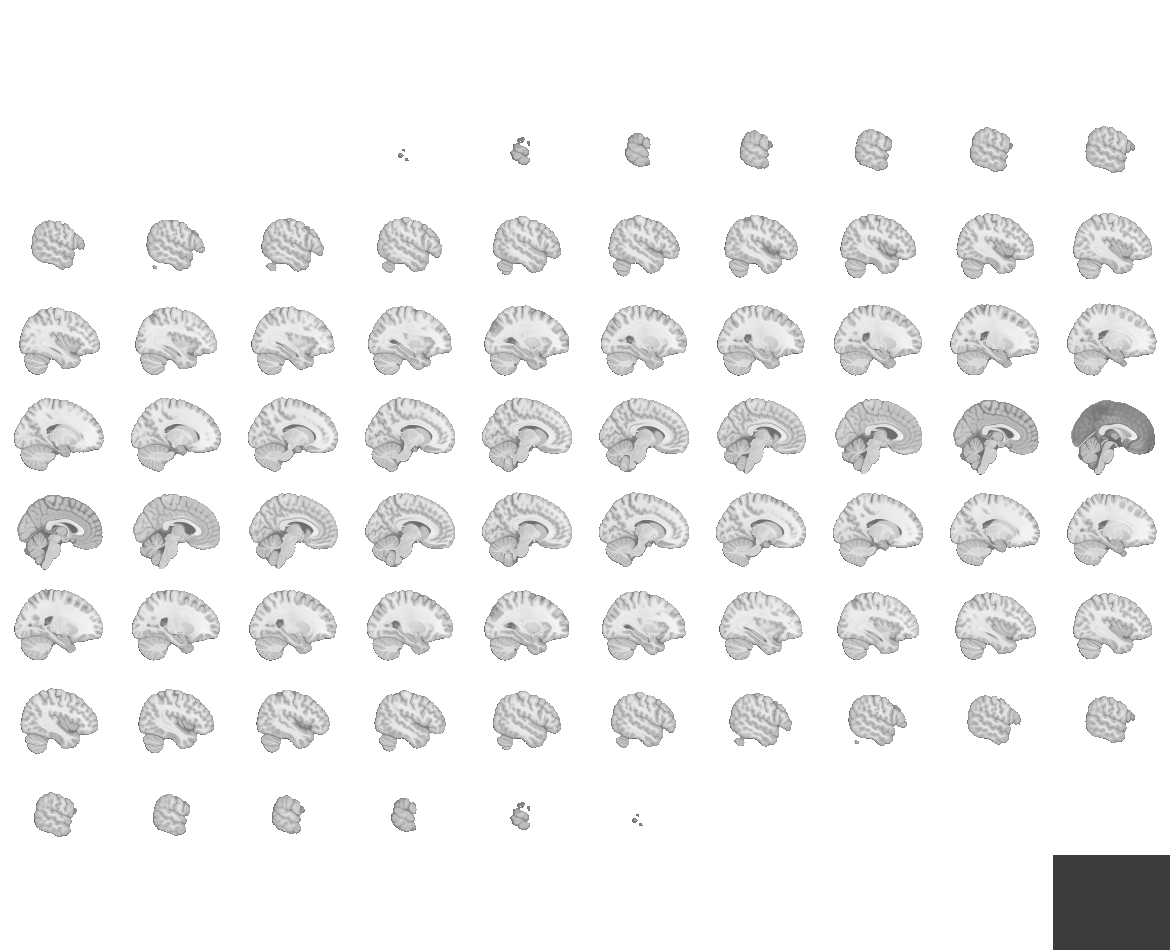
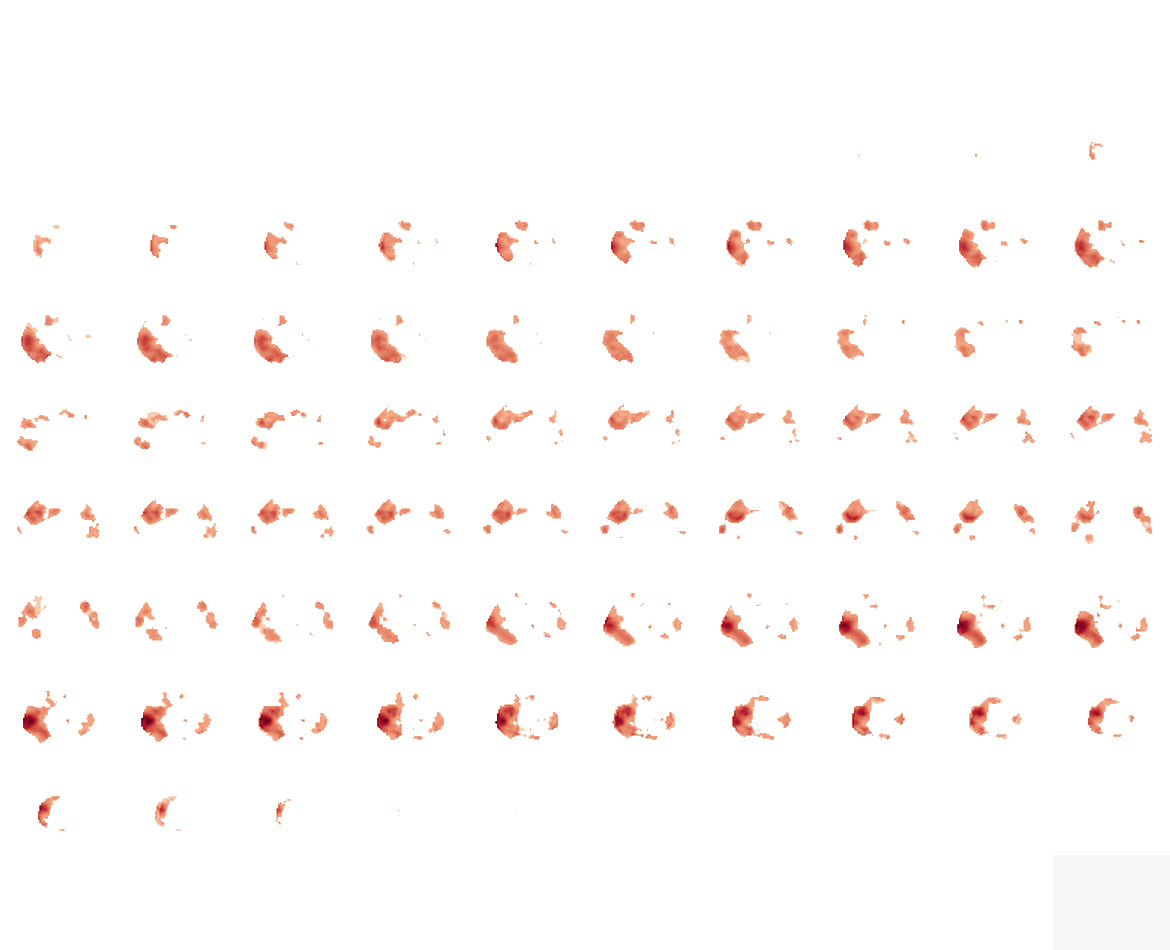

neutral_20


C:\Users\simona.sartan\AppData\Local\Temp\ipykernel_26768\2108539131.py:4: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  plotting.view_img(
C:\Users\simona.sartan\AppData\Local\Temp\ipykernel_26768\2108539131.py:4: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.view_img(



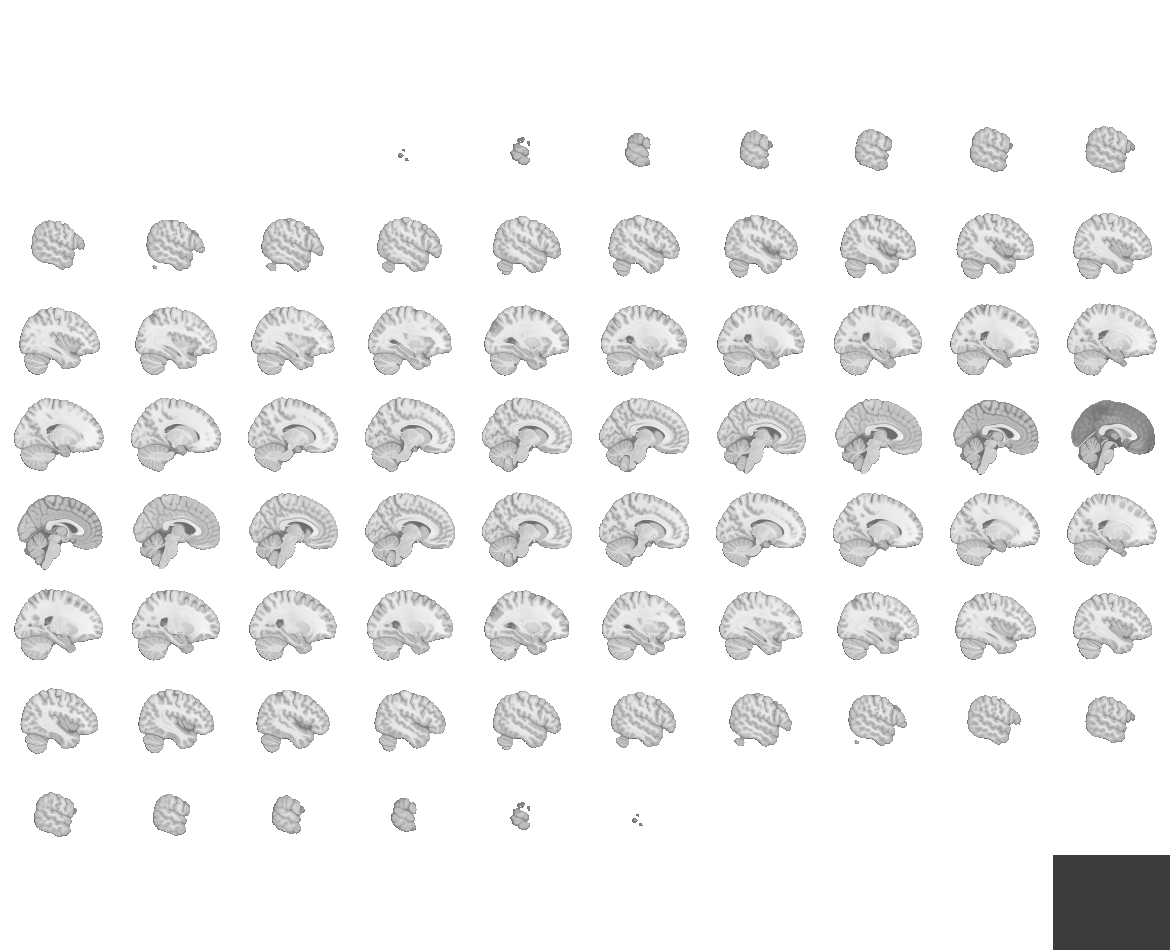
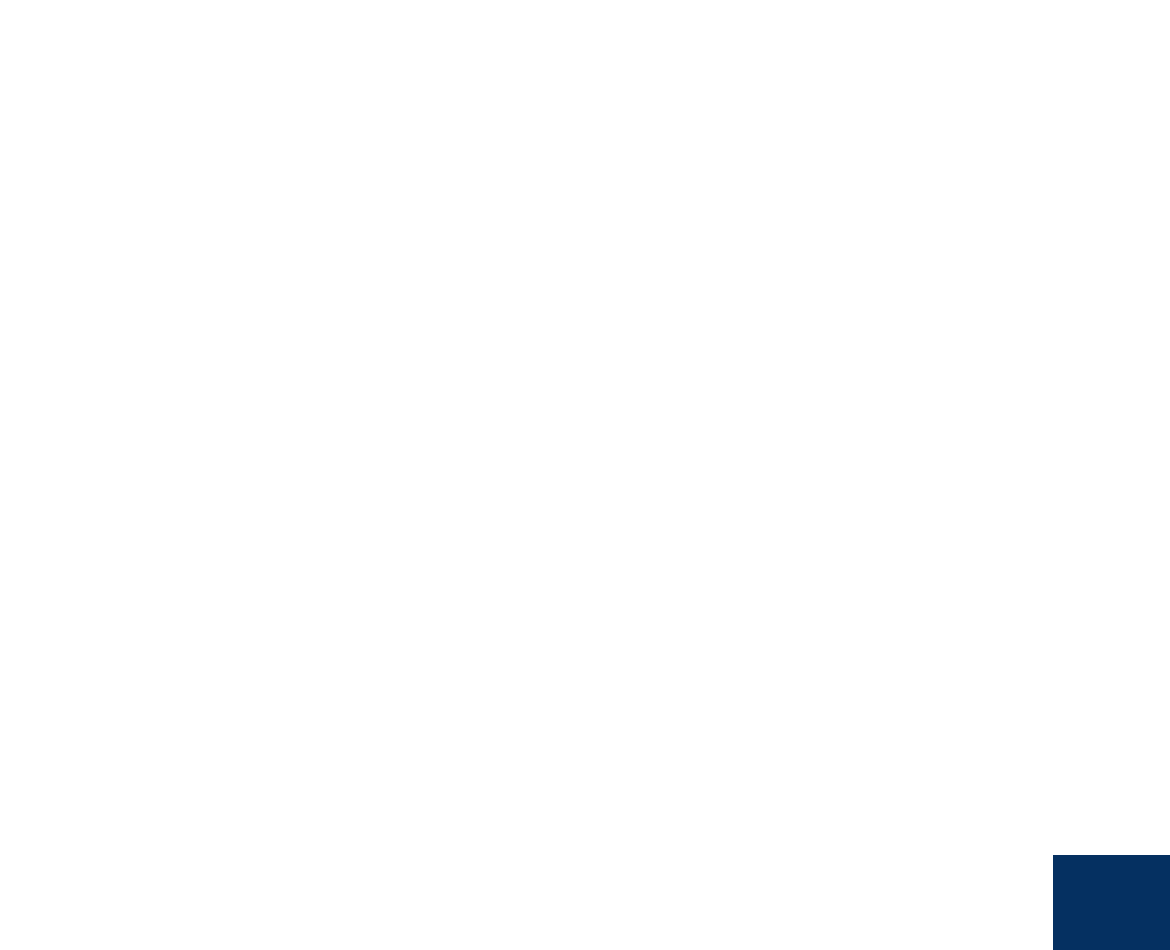

In [8]:
for row in summaries:
    print(row["case"])
    display(
        plotting.view_img(
            nib.load(row["output"]),
            draw_cross=False,
            black_bg=False,
            threshold=0,
            title=f"{row['case']} — signed FDR-significant t-values",
        )
    )